# 03 — Modelagem

**Dimensão 5 da rúbrica — 20 pontos.**

Mínimo de **dois** classificadores distintos. Um único modelo zera 8 dos 20 pontos.

In [6]:
# ============================================================
# 1. CONFIGURAÇÃO DO AMBIENTE
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa para garantir reprodutibilidade
RANDOM_STATE = 42

# Repositório do projeto
REPO_URL = "https://github.com/andrerochadeoliveira/postech-tech-challenge-fase2-template.git"
PROJECT_PATH = Path("/content/postech-tech-challenge-fase2-template")

# Clona o repositório caso ele ainda não esteja disponível
if not PROJECT_PATH.exists():
    !git clone {REPO_URL}
else:
    print("Repositório já disponível nesta sessão.")

# Caminho da base pré-processada pelo notebook 02
DATA_PATH = PROJECT_PATH / "data" / "processed" / "dataset_preprocessed.csv"

# Variável-alvo
TARGET = "target"

pd.set_option("display.max_columns", None)

print("\nDiretório do projeto:")
print(PROJECT_PATH)

print("\nArquivo esperado:")
print(DATA_PATH)

Repositório já disponível nesta sessão.

Diretório do projeto:
/content/postech-tech-challenge-fase2-template

Arquivo esperado:
/content/postech-tech-challenge-fase2-template/data/processed/dataset_preprocessed.csv


In [7]:
# ============================================================
# ATUALIZAÇÃO DO REPOSITÓRIO COM AS SUAS ALTERAÇÕES DO GITHUB
# ============================================================

# Entra no diretório do projeto e puxa as atualizações do GitHub
!cd {PROJECT_PATH} && git pull

Already up to date.


In [3]:
# ============================================================
# 2. EXECUÇÃO DO PRÉ-PROCESSAMENTO
# ============================================================

# Executa o notebook 02 para gerar a base pré-processada
!jupyter nbconvert \
    --to notebook \
    --execute \
    "$PROJECT_PATH/notebooks/02_preprocessamento.ipynb" \
    --output "/tmp/02_preprocessamento_executado.ipynb"

[NbConvertApp] Converting notebook /content/postech-tech-challenge-fase2-template/notebooks/02_preprocessamento.ipynb to notebook
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unh

In [4]:
# ============================================================
# VERIFICAÇÃO DA BASE PRÉ-PROCESSADA
# ============================================================

print("Arquivo existe:", DATA_PATH.exists())

if DATA_PATH.exists():
    tamanho_mb = DATA_PATH.stat().st_size / (1024 ** 2)
    print(f"Tamanho do arquivo: {tamanho_mb:.2f} MB")
    print("Caminho:", DATA_PATH)
else:
    raise FileNotFoundError(
        "O arquivo dataset_preprocessed.csv não foi gerado pelo "
        "notebook 02."
    )

Arquivo existe: True
Tamanho do arquivo: 5.15 MB
Caminho: /content/postech-tech-challenge-fase2-template/data/processed/dataset_preprocessed.csv


In [5]:
df = pd.read_csv(DATA_PATH)

print("Base carregada com sucesso.")
print("Dimensão:", df.shape)

df.head()

Base carregada com sucesso.
Dimensão: (16541, 53)


,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,Age,Employed,Year_employed,Gender,Own_car,Own_realty,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Nao_informado,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,Income_per_capta,Ratio_life_employed,Assets_score,target,grupo_perfil
0,5008804,0,427500.0,1,0,0,2.0,32.867899,1,12.435318,1,1,1,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,213750.0,0.378342,2,0,16483439949979387252
1,5008805,0,427500.0,1,0,0,2.0,32.867899,1,12.435318,1,1,1,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,213750.0,0.378342,2,0,16483439949979387252
2,5008806,0,112500.0,0,0,0,2.0,58.792608,1,3.104723,1,1,1,False,False,False,True,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,56250.0,0.052808,2,0,9121052152296500426
3,5008810,0,270000.0,0,1,1,1.0,52.320329,1,8.353183,0,0,1,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,270000.0,0.159655,1,0,2453973607929646457
4,5008811,0,270000.0,0,1,1,1.0,52.320329,1,8.353183,0,0,1,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,270000.0,0.159655,1,0,2453973607929646457


## 1. Split treino/teste

A base foi dividida em conjuntos de treinamento e teste, utilizando uma proporção de 80% e 20%, respectivamente.

Foi utilizado `stratify=y` para preservar a proporção das classes nos dois conjuntos, uma vez que a variável-alvo apresenta forte desbalanceamento.

In [6]:
# ============================================================
# 3. DEFINIÇÃO DAS VARIÁVEIS E SPLIT TREINO/TESTE
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

# Variável-alvo
y = df[TARGET]

# Variáveis explicativas
# ID e grupo_perfil não serão utilizados como preditores.
X = df.drop(
    columns=[TARGET, "ID", "grupo_perfil"],
    errors="ignore"
)

grupos = df["grupo_perfil"]

divisor = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
idx_train, idx_test = next(divisor.split(X, y, groups=grupos))

X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]
grupos_train = grupos.iloc[idx_train]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

print("\nDistribuição do target:")
print(y.value_counts())

print("\nProporção do target:")
print(y.value_counts(normalize=True))

print("Treino:", X_train.shape, f"— taxa de mau pagador: {y_train.mean():.4%}")
print("Teste: ", X_test.shape, f"— taxa de mau pagador: {y_test.mean():.4%}")
print("Positivos no treino:", int(y_train.sum()), "| no teste:", int(y_test.sum()))
print("Clientes do teste com gêmeo no treino:", f"{grupos.iloc[idx_test].isin(set(grupos_train)).mean():.0%}")

Dimensão de X: (16541, 50)
Dimensão de y: (16541,)

Distribuição do target:
target
0    15233
1     1308
Name: count, dtype: int64

Proporção do target:
target
0    0.920924
1    0.079076
Name: proportion, dtype: float64
Treino: (13255, 50) — taxa de mau pagador: 7.5217%
Teste:  (3286, 50) — taxa de mau pagador: 9.4644%
Positivos no treino: 997 | no teste: 311
Clientes do teste com gêmeo no treino: 0%


In [32]:
# ============================================================
# 3. DEFINIÇÃO DAS VARIÁVEIS E SPLIT TREINO/TESTE
# ============================================================

#from sklearn.model_selection import train_test_split

# Variável-alvo
#y = df[TARGET]

# Variáveis explicativas
# ID e grupo_perfil não serão utilizados como preditores.
#X = df.drop(
#    columns=[TARGET, "ID", "grupo_perfil"],
#    errors="ignore"
#)

#print("Dimensão de X:", X.shape)
#print("Dimensão de y:", y.shape)

#print("\nDistribuição do target:")
#print(y.value_counts())

#print("\nProporção do target:")
#print(y.value_counts(normalize=True))

In [33]:
#X_train, X_test, y_train, y_test = train_test_split(
#    X,
#    y,
#    test_size=0.20,
#    stratify=y,
#    random_state=RANDOM_STATE
#)

#print("Treino:", X_train.shape)
#print("Teste:", X_test.shape)

#print("\nDistribuição do target no treino:")
#print(y_train.value_counts(normalize=True))

#print("\nDistribuição do target no teste:")
#print(y_test.value_counts(normalize=True))

In [7]:
# ============================================================
# 4. VERIFICAÇÃO DAS BIBLIOTECAS DE MODELAGEM
# ============================================================

import sklearn
import imblearn

print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)

scikit-learn: 1.6.1
imbalanced-learn: 0.14.2


## 2. Modelos candidatos

Foram avaliados dois classificadores distintos: **Regressão Logística** e **Random Forest**.

Considerando o forte desbalanceamento da variável-alvo, foram comparadas três estratégias para cada classificador:

- modelo sem tratamento específico do desbalanceamento;
- ponderação das classes com `class_weight="balanced"`;
- sobreamostragem da classe minoritária utilizando **SMOTE**.

Os modelos foram estruturados em `Pipeline`, evitando vazamento de informação durante a validação cruzada.

In [8]:
# ============================================================
# 5. MODELOS CANDIDATOS
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# ------------------------------------------------------------
# Regressão Logística
# ------------------------------------------------------------

modelos = {

    "logistic_baseline": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    "logistic_class_weight": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "logistic_smote": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),


    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------

    "random_forest_baseline": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "random_forest_class_weight": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "random_forest_smote": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

print("Modelos configurados:")
for nome in modelos:
    print("-", nome)

Modelos configurados:
- logistic_baseline
- logistic_class_weight
- logistic_smote
- random_forest_baseline
- random_forest_class_weight
- random_forest_smote


## 3. Validação cruzada e comparação

Foi utilizada **validação cruzada estratificada com 5 folds**, mantendo a proporção das classes em cada divisão.

Foram comparadas seis combinações entre os dois classificadores avaliados — **Regressão Logística** e **Random Forest** — e três estratégias para lidar com o desbalanceamento da variável-alvo:

- modelo sem tratamento específico do desbalanceamento;
- ponderação das classes com `class_weight="balanced"`;
- sobreamostragem da classe minoritária utilizando **SMOTE**.

O **F1-score** foi adotado como principal métrica para comparação dos modelos, por considerar simultaneamente Precision e Recall. Como métricas complementares, foram avaliados **Recall, Precision, ROC-AUC e Average Precision**.

Os resultados apresentados a seguir permitem comparar o desempenho das diferentes combinações e identificar a estratégia mais adequada para a etapa de treinamento final.

In [9]:
# ============================================================
# 6. VALIDAÇÃO CRUZADA
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate

# Validação cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Métricas utilizadas na comparação
scoring = {
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

resultados_cv = []

for nome, modelo in modelos.items():

    print(f"Avaliando: {nome}")

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    resultados_cv.append({
        "modelo": nome,
        "f1_mean": scores["test_f1"].mean(),
        "f1_std": scores["test_f1"].std(),
        "recall_mean": scores["test_recall"].mean(),
        "precision_mean": scores["test_precision"].mean(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "average_precision_mean": scores["test_average_precision"].mean()
    })

resultados_cv = pd.DataFrame(resultados_cv)

resultados_cv = resultados_cv.sort_values(
    "f1_mean",
    ascending=False
).reset_index(drop=True)

resultados_cv

Avaliando: logistic_baseline


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Avaliando: logistic_class_weight
Avaliando: logistic_smote
Avaliando: random_forest_baseline
Avaliando: random_forest_class_weight
Avaliando: random_forest_smote


,modelo,f1_mean,f1_std,recall_mean,precision_mean,roc_auc_mean,average_precision_mean
0,random_forest_baseline,0.906083,0.012082,0.838492,0.985950,0.969555,0.906380
1,random_forest_class_weight,0.905480,0.012353,0.837492,0.985912,0.970178,0.905342
2,random_forest_smote,0.895408,0.011190,0.838492,0.961036,0.972227,0.904250
3,logistic_class_weight,0.175896,0.006205,0.552693,0.104608,0.610061,0.123715
4,logistic_smote,0.174939,0.004039,0.550673,0.104003,0.605808,0.120636
5,logistic_baseline,0.000000,0.000000,0.000000,0.000000,0.609689,0.130191


In [ ]:
# ============================================================
# 7. SELEÇÃO DO MODELO
# ============================================================

# O modelo é selecionado com base no maior F1 médio
melhor_modelo_nome = resultados_cv.iloc[0]["modelo"]

melhor_modelo = modelos[melhor_modelo_nome]

print("Modelo selecionado:")
print(melhor_modelo_nome)

print("\nDesempenho médio na validação cruzada:")
print(
    resultados_cv.loc[
        resultados_cv["modelo"] == melhor_modelo_nome,
        [
            "f1_mean",
            "recall_mean",
            "precision_mean",
            "roc_auc_mean",
            "average_precision_mean"
        ]
    ].to_string(index=False)
)

Modelo selecionado:
random_forest_class_weight

Desempenho médio na validação cruzada:
 f1_mean  recall_mean  precision_mean  roc_auc_mean  average_precision_mean
0.137664     0.159771        0.121082      0.654752                0.070133


# 4. Treinamento do modelo selecionado

In [ ]:
# ============================================================
# 8. TREINAMENTO DO MODELO SELECIONADO
# ============================================================

melhor_modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


## 5. Otimização do ponto de corte

A classe positiva apresenta forte desbalanceamento (2,35% dos registros).
Por isso, o ponto de corte padrão de 0,50 pode não ser o mais adequado.

O ponto de corte será definido utilizando previsões out-of-fold no conjunto
de treinamento, evitando o uso do conjunto de teste para escolha do threshold.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Previsões out-of-fold do melhor modelo
# ------------------------------------------------------------

cv_threshold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

prob_oof = cross_val_predict(
    melhor_modelo,
    X_train,
    y_train,
    cv=cv_threshold,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Previsões out-of-fold geradas.")
print(f"Quantidade de observações: {len(prob_oof):,}")

Previsões out-of-fold geradas.
Quantidade de observações: 17,355


In [ ]:
# ------------------------------------------------------------
# Avaliação de diferentes pontos de corte
# ------------------------------------------------------------

thresholds = np.arange(0.05, 0.96, 0.01)

resultados_threshold = []

for threshold in thresholds:

    y_pred = (prob_oof >= threshold).astype(int)

    precision = precision_score(
        y_train,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        y_pred,
        zero_division=0
    )

    resultados_threshold.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

df_threshold = pd.DataFrame(resultados_threshold)

df_threshold.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
23,0.28,0.122523,0.167076,0.141372
22,0.27,0.121864,0.167076,0.140933
21,0.26,0.121864,0.167076,0.140933
35,0.40,0.123162,0.164619,0.140904
36,0.41,0.123162,0.164619,0.140904
34,0.39,0.123162,0.164619,0.140904
37,0.42,0.123162,0.164619,0.140904
33,0.38,0.123162,0.164619,0.140904
17,0.22,0.120419,0.169533,0.140816
20,0.25,0.121646,0.167076,0.140787


In [ ]:
resultado_050 = df_threshold[
    np.isclose(df_threshold["threshold"], 0.50)
].iloc[0]

print("Threshold 0,50")
print(f"Precision: {resultado_050['precision']:.4f}")
print(f"Recall:    {resultado_050['recall']:.4f}")
print(f"F1:        {resultado_050['f1']:.4f}")

print("\nMelhor threshold")
melhor_linha = df_threshold.loc[
    df_threshold["f1"].idxmax()
]

print(f"Threshold: {melhor_linha['threshold']:.2f}")
print(f"Precision: {melhor_linha['precision']:.4f}")
print(f"Recall:    {melhor_linha['recall']:.4f}")
print(f"F1:        {melhor_linha['f1']:.4f}")

Threshold 0,50
Precision: 0.1210
Recall:    0.1597
F1:        0.1377

Melhor threshold
Threshold: 0.28
Precision: 0.1225
Recall:    0.1671
F1:        0.1414


In [ ]:
# ------------------------------------------------------------
# Identificação do melhor ponto de corte
# ------------------------------------------------------------

melhor_linha = df_threshold.loc[
    df_threshold["f1"].idxmax()
]

melhor_threshold = melhor_linha["threshold"]
melhor_f1 = melhor_linha["f1"]

print(f"Melhor threshold: {melhor_threshold:.2f}")
print(f"Melhor F1 no treinamento OOF: {melhor_f1:.4f}")

Melhor threshold: 0.28
Melhor F1 no treinamento OOF: 0.1414


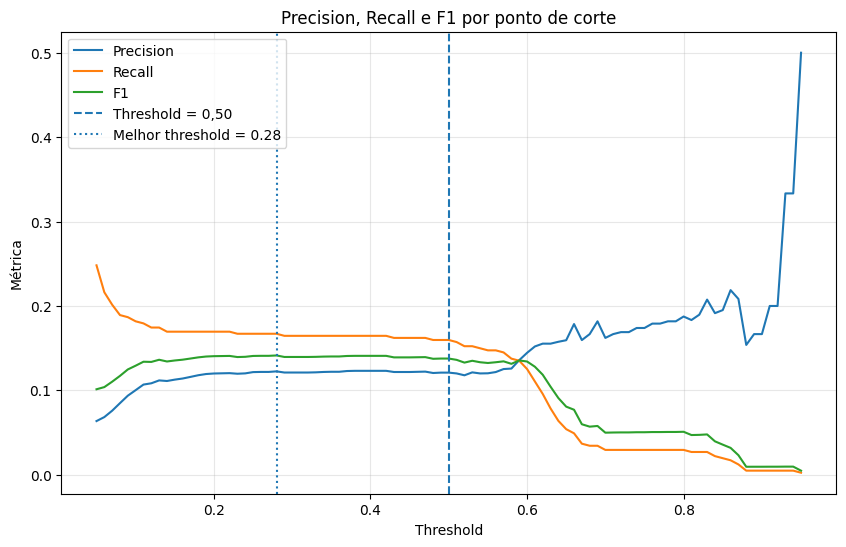

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    df_threshold["threshold"],
    df_threshold["precision"],
    label="Precision"
)

plt.plot(
    df_threshold["threshold"],
    df_threshold["recall"],
    label="Recall"
)

plt.plot(
    df_threshold["threshold"],
    df_threshold["f1"],
    label="F1"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Threshold = 0,50"
)

plt.axvline(
    melhor_threshold,
    linestyle=":",
    label=f"Melhor threshold = {melhor_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Precision, Recall e F1 por ponto de corte")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ------------------------------------------------------------
# Modelo final
# ------------------------------------------------------------

melhor_modelo.fit(X_train, y_train)

prob_test = melhor_modelo.predict_proba(X_test)[:, 1]

y_pred_test_050 = (
    prob_test >= 0.50
).astype(int)

y_pred_test_otimizado = (
    prob_test >= melhor_threshold
).astype(int)

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

comparacao_threshold = pd.DataFrame({
    "Métrica": [
        "Precision",
        "Recall",
        "F1"
    ],
    "Threshold 0,50": [
        precision_score(y_test, y_pred_test_050, zero_division=0),
        recall_score(y_test, y_pred_test_050, zero_division=0),
        f1_score(y_test, y_pred_test_050, zero_division=0)
    ],
    "Threshold otimizado": [
        precision_score(y_test, y_pred_test_otimizado, zero_division=0),
        recall_score(y_test, y_pred_test_otimizado, zero_division=0),
        f1_score(y_test, y_pred_test_otimizado, zero_division=0)
    ]
})

comparacao_threshold.round(4)

,Métrica,"Threshold 0,50",Threshold otimizado
0,Precision,0.1056,0.1176
1,Recall,0.1863,0.2157
2,F1,0.1348,0.1522


## Conclusão da modelagem

Foram avaliadas seis combinações entre **Regressão Logística** e **Random Forest**, considerando três estratégias para o tratamento do desbalanceamento da variável-alvo: ausência de balanceamento, ponderação das classes (`class_weight="balanced"`) e SMOTE.

A comparação foi realizada por meio de **validação cruzada estratificada com 5 folds**, utilizando o **F1-score** como principal critério de seleção e Recall, Precision, ROC-AUC e Average Precision como métricas complementares.

O **Random Forest com `class_weight="balanced"` apresentou o maior F1 médio (0,1377)** entre as alternativas avaliadas e foi selecionado para a etapa final. A ponderação das classes apresentou desempenho superior ao SMOTE para o Random Forest, enquanto as versões balanceadas da Regressão Logística apresentaram maior Recall, porém Precision muito baixa, resultando em F1 inferior.

Considerando o forte desbalanceamento da variável-alvo, também foi avaliado o ponto de corte das probabilidades preditas. As previsões out-of-fold indicaram **0,28 como ponto de corte com maior F1**, em comparação ao threshold padrão de 0,50.

No conjunto de teste, a utilização do threshold otimizado aumentou o F1 de **0,1348 para 0,1522**, acompanhado de aumento de Precision de **0,1056 para 0,1176** e de Recall de **0,1863 para 0,2157**.

Apesar da melhora, o desempenho final ainda é moderado, indicando que as variáveis disponíveis apresentam poder preditivo limitado para a identificação da classe positiva. O modelo, entretanto, demonstra capacidade de discriminação superior à simples classificação baseada na prevalência da classe.

Dessa forma, foi definido para a etapa de avaliação o **Random Forest com `class_weight="balanced"` e ponto de corte de 0,28**.

A avaliação detalhada do modelo será apresentada no **Notebook 04 — Avaliação e Interpretação**, incluindo métricas, matriz de confusão, importância das variáveis, implicações práticas e limitações.